<a href="https://colab.research.google.com/github/manvadityasingh16/Celebal-repo/blob/main/Text_Generation_RNN_LSTM_GRU_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [2]:
import os
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Embedding, GRU, LSTM, SimpleRNN
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [3]:
# --- Source corpus text ---
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''

raw_lines = corpus.strip().split('\n')
cleaned_lines = list(filter(None, (line.strip() for line in raw_lines)))
cleaned_corpus = '\n'.join(cleaned_lines)

print("--- Cleaned Corpus ---")
print(cleaned_corpus)

tokenizer = Tokenizer()
tokenizer.fit_on_texts([cleaned_corpus])
total_words = len(tokenizer.word_index) + 1

print("\nVocabulary size (total_words):", total_words)
print("Word → Index mapping (sample):")
sample_items = list(tokenizer.word_index.items())[:8]
for word, idx in sample_items:
    print(f"  '{word}' → {idx}")


--- Cleaned Corpus ---
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences

Vocabulary size (total_words): 37
Word → Index mapping (sample):
  'deep' → 1
  'learning' → 2
  'is' → 3
  'lstm' → 4
  'models' → 5
  'transforming' → 6
  'artificial' → 7
  'intelligence' → 8


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [4]:
def make_ngrams(token_list):
    """Build every prefix n-gram (length >= 2) from a token list."""
    return [token_list[:i + 1] for i in range(1, len(token_list))]

input_sequences = []
for line in cleaned_lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    input_sequences.extend(make_ngrams(token_list))

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X, y = input_sequences[:, :-1], input_sequences[:, -1]

print("Total n-gram sequences created:", len(input_sequences))
print("Max sequence length (max_len):", max_len)
print("X shape:", X.shape, "  ← input to the model")
print("y shape:", y.shape, "  ← target word index")

print("\nSample X[0] (padded):", X[0])
print("Sample y[0] (target word index):", y[0])


Total n-gram sequences created: 35
Max sequence length (max_len): 8
X shape: (35, 7)   ← input to the model
y shape: (35,)   ← target word index

Sample X[0] (padded): [0 0 0 0 0 0 1]
Sample y[0] (target word index): 2


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [5]:
rnn_model = Sequential()
rnn_model.add(Embedding(total_words, 32, input_length=max_len - 1))
rnn_model.add(SimpleRNN(64))
rnn_model.add(Dense(total_words, activation='softmax'))

rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [6]:
lstm_model = Sequential()
lstm_model.add(Embedding(total_words, 32, input_length=max_len - 1))
lstm_model.add(LSTM(64))
lstm_model.add(Dense(total_words, activation='softmax'))

lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [7]:
gru_model = Sequential()
gru_model.add(Embedding(total_words, 32, input_length=max_len - 1))
gru_model.add(GRU(64))
gru_model.add(Dense(total_words, activation='softmax'))

gru_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 🏋️ Step 5: Compile and Train All Three Models
- Loss: `sparse_categorical_crossentropy` — used when labels are plain integers (not one-hot)
- Optimizer: `adam` — adaptive learning rate, same config for all three models
- `verbose=0` — suppresses per-epoch output to keep the notebook clean

In [9]:
compile_args = dict(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

models_to_train = [
    ("Vanilla RNN", rnn_model),
    ("LSTM", lstm_model),
    ("GRU", gru_model),
]

histories = {}
for name, model in models_to_train:
    model.compile(**compile_args)
    print(f"Training {name}...")
    history = model.fit(X, y, epochs=100, verbose=0)
    histories[name] = history
    print(f"  Final loss: {history.history['loss'][-1]:.4f}  |  Final accuracy: {history.history['accuracy'][-1]:.4f}")

rnn_history, lstm_history, gru_history = histories["Vanilla RNN"], histories["LSTM"], histories["GRU"]

print("\n✅ All three models trained successfully!")


Training Vanilla RNN...
  Final loss: 0.7159  |  Final accuracy: 0.9143
Training LSTM...
  Final loss: 1.5417  |  Final accuracy: 0.6857
Training GRU...
  Final loss: 1.2037  |  Final accuracy: 0.8571

✅ All three models trained successfully!


## 📉 Compare Training Loss

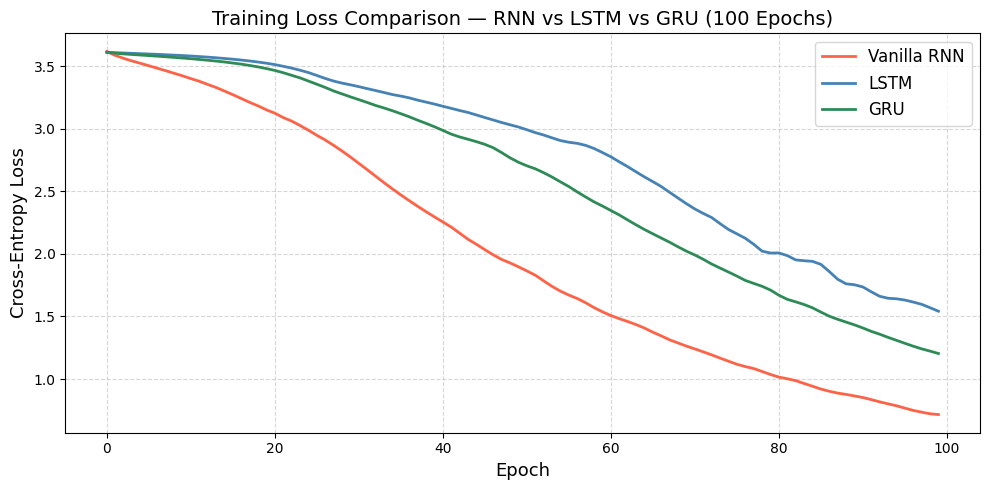

Interpretation:
  - A steeper early drop means faster learning
  - A lower final loss means better convergence
  - Smoother curve = more stable gradient flow


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

loss_curves = {
    'Vanilla RNN': ('tomato', rnn_history),
    'LSTM': ('steelblue', lstm_history),
    'GRU': ('seagreen', gru_history),
}

for label, (color, history) in loss_curves.items():
    ax.plot(history.history['loss'], label=label, color=color, linewidth=2)

ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("Cross-Entropy Loss", fontsize=13)
ax.set_title("Training Loss Comparison — RNN vs LSTM vs GRU (100 Epochs)", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

print("Interpretation:")
print("  - A steeper early drop means faster learning")
print("  - A lower final loss means better convergence")
print("  - Smoother curve = more stable gradient flow")


# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [11]:
def generate_text(model, seed_text, next_words=5):
    """
    Generates text by predicting one word at a time.

    Parameters:
        model      : trained Keras model (RNN, LSTM, or GRU)
        seed_text  : starting phrase (string)
        next_words : how many words to generate (int)

    Returns:
        Full generated string (seed + predicted words)
    """
    index_to_word = {index: word for word, index in tokenizer.word_index.items()}

    for _ in range(next_words):
        # Step 1: Convert current text to token list
        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        # Step 2: Pad to match training input shape
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding='pre')

        # Step 3: Get probability scores for every word in vocabulary
        probabilities = model.predict(token_list, verbose=0)  # shape: (1, total_words)

        # Step 4: Pick the word index with the highest probability
        predicted_index = int(np.argmax(probabilities, axis=-1)[0])

        # Step 5: Reverse look-up: integer index → actual word string
        predicted_word = index_to_word.get(predicted_index, "")

        # Step 6: Append word and continue loop
        seed_text = f"{seed_text} {predicted_word}"

    return seed_text

print("generate_text() function defined successfully.")


generate_text() function defined successfully.


## 🧪 Generate Text Samples

In [12]:
seed_phrase = "deep learning"

outputs = {
    "RNN": generate_text(rnn_model, seed_phrase, next_words=5),
    "LSTM": generate_text(lstm_model, seed_phrase, next_words=5),
    "GRU": generate_text(gru_model, seed_phrase, next_words=5),
}

print("Seed phrase:", f'"{seed_phrase}"')
print()
for name, text in outputs.items():
    print(f"{name:<5}: {text}")


Seed phrase: "deep learning"

RNN  : deep learning models can generate meaningful sentences
LSTM : deep learning is transforming artificial intelligence intelligence
GRU  : deep learning is faster and than lstm


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

---
# 📚 Student Learning Tasks

Below are all **5 beginner-level customization tasks** implemented from scratch.
Each task is in its own cell so you can experiment independently.

---

## ✅ Task 1 — Replace Corpus with a Custom Paragraph

Instead of the boilerplate text, we write our own paragraph to train on.
The tokenizer re-learns from scratch on this new data.

In [13]:
custom_corpus = '''
the sun rises in the east and sets in the west
birds fly high in the sky every morning
rivers flow through forests and reach the sea
mountains stand tall and proud under the blue sky
the wind carries seeds across the open fields
nature is beautiful and full of wonder every day
'''

custom_lines = [line.strip() for line in custom_corpus.strip().splitlines() if line.strip()]

custom_tokenizer = Tokenizer()
custom_tokenizer.fit_on_texts(custom_lines)
custom_total_words = len(custom_tokenizer.word_index) + 1

custom_sequences = []
for line in custom_lines:
    token_list = custom_tokenizer.texts_to_sequences([line])[0]
    custom_sequences.extend(make_ngrams(token_list))

custom_max_len = max(len(seq) for seq in custom_sequences)
custom_sequences = pad_sequences(custom_sequences, maxlen=custom_max_len, padding='pre')

X_custom, y_custom = custom_sequences[:, :-1], custom_sequences[:, -1]

print("Custom vocabulary size:", custom_total_words)
print("Custom X shape:", X_custom.shape)
print("Ready to train on custom corpus! ✅")


Custom vocabulary size: 40
Custom X shape: (47, 10)
Ready to train on custom corpus! ✅


## ✅ Task 2 — Upscale Embedding Dimensions (32 → 64)

A larger embedding dimension gives each word a richer vector representation,
which helps the model learn finer semantic differences between words.

In [14]:
embedding_dim = 64   # was 32, now doubled

def build_model(rnn_layer):
    return Sequential([
        Embedding(total_words, embedding_dim, input_length=max_len - 1),
        rnn_layer,
        Dense(total_words, activation='softmax')
    ])

rnn_model_t2 = build_model(SimpleRNN(64))
lstm_model_t2 = build_model(LSTM(64))
gru_model_t2 = build_model(GRU(64))

print(f"Embedding dimension set to: {embedding_dim}")
print("Models with upscaled embeddings ready. ✅")
rnn_model_t2.summary()


Embedding dimension set to: 64
Models with upscaled embeddings ready. ✅


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## ✅ Task 3 — Expand Training to 200 Epochs

More epochs give the model more passes over the data,
allowing it to refine its weights further and reduce loss.

Training RNN for 200 epochs...
  RNN  final loss: 0.1161
Training LSTM for 200 epochs...
  LSTM final loss: 0.4180
Training GRU for 200 epochs...
  GRU  final loss: 0.1558


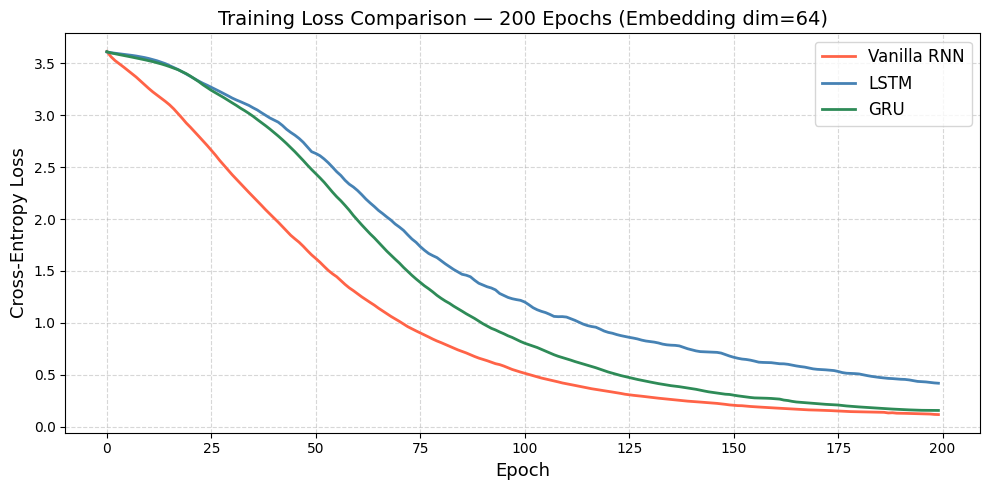

200-epoch training complete! ✅


In [15]:
num_epochs = 200   # was 100, now doubled

compile_args = dict(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

models_200 = [
    ("RNN", rnn_model_t2, 'tomato'),
    ("LSTM", lstm_model_t2, 'steelblue'),
    ("GRU", gru_model_t2, 'seagreen'),
]

histories_200 = {}
for name, model, color in models_200:
    model.compile(**compile_args)
    print(f"Training {name} for {num_epochs} epochs...")
    hist = model.fit(X, y, epochs=num_epochs, verbose=0)
    histories_200[name] = (hist, color)
    print(f"  {name:<4} final loss: {hist.history['loss'][-1]:.4f}")

rnn_hist_200, lstm_hist_200, gru_hist_200 = (histories_200[k][0] for k in ("RNN", "LSTM", "GRU"))

fig, ax = plt.subplots(figsize=(10, 5))
labels = {"RNN": "Vanilla RNN", "LSTM": "LSTM", "GRU": "GRU"}
for name, (hist, color) in histories_200.items():
    ax.plot(hist.history['loss'], label=labels[name], color=color, linewidth=2)

ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("Cross-Entropy Loss", fontsize=13)
ax.set_title("Training Loss Comparison — 200 Epochs (Embedding dim=64)", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

print("200-epoch training complete! ✅")


## ✅ Task 4 — Widen Hidden Layers (64 → 128 units)

More hidden units = larger internal state = more capacity to memorize patterns.
This is useful when the corpus is long or complex.

In [16]:
hidden_units = 128   # was 64

def build_wide_model(rnn_layer):
    return Sequential([
        Embedding(total_words, 32, input_length=max_len - 1),
        rnn_layer,
        Dense(total_words, activation='softmax')
    ])

rnn_model_t4 = build_wide_model(SimpleRNN(hidden_units))
lstm_model_t4 = build_wide_model(LSTM(hidden_units))
gru_model_t4 = build_wide_model(GRU(hidden_units))

compile_args = dict(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

results_t4 = {}
for name, model in [("RNN", rnn_model_t4), ("LSTM", lstm_model_t4), ("GRU", gru_model_t4)]:
    model.compile(**compile_args)
    results_t4[name] = model.fit(X, y, epochs=100, verbose=0)

rnn_hist_t4, lstm_hist_t4, gru_hist_t4 = results_t4["RNN"], results_t4["LSTM"], results_t4["GRU"]

print(f"Hidden units = {hidden_units}")
print(f"RNN  final loss: {rnn_hist_t4.history['loss'][-1]:.4f}")
print(f"LSTM final loss: {lstm_hist_t4.history['loss'][-1]:.4f}")
print(f"GRU  final loss: {gru_hist_t4.history['loss'][-1]:.4f}")
print("Models with 128 hidden units trained. ✅")


Hidden units = 128
RNN  final loss: 0.3633
LSTM final loss: 1.0959
GRU  final loss: 0.6923
Models with 128 hidden units trained. ✅


## ✅ Task 5 — Generate 10 Words per Seed Prompt

We increase `next_words` from 5 to **10** and test all three trained 128-unit models
on the same seed phrase.

In [17]:
num_words_to_generate = 10   # was 5
seed_phrase = "deep learning"

generated = {
    "RNN  (128 units, 10 words)": generate_text(rnn_model_t4, seed_phrase, next_words=num_words_to_generate),
    "LSTM (128 units, 10 words)": generate_text(lstm_model_t4, seed_phrase, next_words=num_words_to_generate),
    "GRU  (128 units, 10 words)": generate_text(gru_model_t4, seed_phrase, next_words=num_words_to_generate),
}

print(f"Seed: '{seed_phrase}' | Generating {num_words_to_generate} words")
print()
for label, text in generated.items():
    print(f"{label}:", text)


Seed: 'deep learning' | Generating 10 words

RNN  (128 units, 10 words): deep learning is transforming artificial intelligence sentences simpler are generate data sequential
LSTM (128 units, 10 words): deep learning is is generate intelligence intelligence sentences lstm lstm word word
GRU  (128 units, 10 words): deep learning models can generate meaningful sentences sentences data data data data


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**